In [0]:
# Check file path
import os
volume_path = "/Volumes/workspace/default/ecommerce_volume"
files = os.listdir(volume_path)
print(files)

['orders.csv']


In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, round, when, month, year, sum, avg, count, desc

spark = SparkSession.builder.appName("Ecommerce_Sales_Analytics").getOrCreate()

# Load data
df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .load("/Volumes/workspace/default/ecommerce_volume/orders.csv")

print(f"Total Records: {df.count()}")
print(f"Total Columns: {len(df.columns)}")
df.printSchema()

Total Records: 9994
Total Columns: 16
root
 |-- Order Id: integer (nullable = true)
 |-- Order Date: date (nullable = true)
 |-- Ship Mode: string (nullable = true)
 |-- Segment: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: integer (nullable = true)
 |-- Region: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Sub Category: string (nullable = true)
 |-- Product Id: string (nullable = true)
 |-- cost price: integer (nullable = true)
 |-- List Price: integer (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- Discount Percent: integer (nullable = true)



In [0]:
# Data Quality Check
print("=== DATA QUALITY REPORT ===")
print(f"\nNull values per column:")
from pyspark.sql.functions import isnan, isnull

for col_name in df.columns:
    null_count = df.filter(isnull(col(col_name))).count()
    print(f"  {col_name}: {null_count}")

print(f"\nDuplicate Records: {df.count() - df.dropDuplicates().count()}")
print(f"\nSample Data:")
df.show(5)

=== DATA QUALITY REPORT ===

Null values per column:
  Order Id: 0
  Order Date: 0
  Ship Mode: 0
  Segment: 0
  Country: 0
  City: 0
  State: 0
  Postal Code: 0
  Region: 0
  Category: 0
  Sub Category: 0
  Product Id: 0
  cost price: 0
  List Price: 0
  Quantity: 0
  Discount Percent: 0

Duplicate Records: 0

Sample Data:
+--------+----------+--------------+---------+-------------+---------------+----------+-----------+------+---------------+------------+---------------+----------+----------+--------+----------------+
|Order Id|Order Date|     Ship Mode|  Segment|      Country|           City|     State|Postal Code|Region|       Category|Sub Category|     Product Id|cost price|List Price|Quantity|Discount Percent|
+--------+----------+--------------+---------+-------------+---------------+----------+-----------+------+---------------+------------+---------------+----------+----------+--------+----------------+
|       1|2023-03-01|  Second Class| Consumer|United States|      Henderso

In [0]:
# TRANSFORMATIONS
from pyspark.sql.functions import col, round, when, month, year, to_date

df_transformed = df \
    .withColumn("Sale Price", 
        round(col("List Price") * (1 - col("Discount Percent") / 100), 2)) \
    .withColumn("Revenue", 
        round(col("Sale Price") * col("Quantity"), 2)) \
    .withColumn("Profit", 
        round((col("Sale Price") - col("cost price")) * col("Quantity"), 2)) \
    .withColumn("Order Year", year(col("Order Date"))) \
    .withColumn("Order Month", month(col("Order Date"))) \
    .withColumn("Profit Category",
        when(col("Profit") > 500, "High")
        .when((col("Profit") >= 0) & (col("Profit") <= 500), "Medium")
        .otherwise("Loss"))

print(f"New features added: 5")
print(f"Total columns now: {len(df_transformed.columns)}")
df_transformed.select("Order Id", "List Price", "Sale Price", "Revenue", "Profit", "Profit Category").show(5)

New features added: 5
Total columns now: 22
+--------+----------+----------+-------+------+---------------+
|Order Id|List Price|Sale Price|Revenue|Profit|Profit Category|
+--------+----------+----------+-------+------+---------------+
|       1|       260|     254.8|  509.6|  29.6|         Medium|
|       2|       730|     708.1| 2124.3| 324.3|         Medium|
|       3|        10|       9.5|   19.0|  -1.0|           Loss|
|       4|       960|     940.8| 4704.0| 804.0|           High|
|       5|        20|      19.0|   38.0|  -2.0|           Loss|
+--------+----------+----------+-------+------+---------------+
only showing top 5 rows


In [0]:
from pyspark.sql.functions import sum, avg, count, desc, round

print("=== BUSINESS INSIGHTS ===")

print("\n1. Revenue by Region:")
df_transformed.groupBy("Region") \
    .agg(round(sum("Revenue"), 2).alias("Total Revenue"),
         round(sum("Profit"), 2).alias("Total Profit"),
         count("Order Id").alias("Total Orders")) \
    .orderBy(desc("Total Revenue")) \
    .show()

print("2. Revenue by Category:")
df_transformed.groupBy("Category") \
    .agg(round(sum("Revenue"), 2).alias("Total Revenue"),
         round(sum("Profit"), 2).alias("Total Profit")) \
    .orderBy(desc("Total Revenue")) \
    .show()

print("3. Top 5 Sub Categories by Profit:")
df_transformed.groupBy("Sub Category") \
    .agg(round(sum("Profit"), 2).alias("Total Profit")) \
    .orderBy(desc("Total Profit")) \
    .show(5)

print("4. Revenue by Year:")
df_transformed.groupBy("Order Year") \
    .agg(round(sum("Revenue"), 2).alias("Total Revenue"),
         count("Order Id").alias("Total Orders")) \
    .orderBy("Order Year") \
    .show()

print("5. Profit Category Distribution:")
df_transformed.groupBy("Profit Category") \
    .count() \
    .orderBy(desc("count")) \
    .show()

=== BUSINESS INSIGHTS ===

1. Revenue by Region:
+-------+-------------+------------+------------+
| Region|Total Revenue|Total Profit|Total Orders|
+-------+-------------+------------+------------+
|   West|    3467409.6|    305289.6|        3203|
|   East|    3257983.8|    295773.8|        2848|
|Central|    2387881.2|    236121.2|        2323|
|  South|    1966053.6|    202743.6|        1620|
+-------+-------------+------------+------------+

2. Revenue by Category:
+---------------+-------------+------------+
|       Category|Total Revenue|Total Profit|
+---------------+-------------+------------+
|     Technology|    3934910.7|    379720.7|
|      Furniture|    3720742.4|    342782.4|
|Office Supplies|    3423675.1|    317425.1|
+---------------+-------------+------------+

3. Top 5 Sub Categories by Profit:
+------------+------------+
|Sub Category|Total Profit|
+------------+------------+
|      Chairs|    153905.7|
|      Phones|    139498.5|
|     Binders|     98802.8|
|      

In [0]:
# Rename columns - remove spaces
df_clean_cols = df_transformed \
    .withColumnRenamed("Order Id", "Order_Id") \
    .withColumnRenamed("Order Date", "Order_Date") \
    .withColumnRenamed("Ship Mode", "Ship_Mode") \
    .withColumnRenamed("Postal Code", "Postal_Code") \
    .withColumnRenamed("Sub Category", "Sub_Category") \
    .withColumnRenamed("Product Id", "Product_Id") \
    .withColumnRenamed("cost price", "Cost_Price") \
    .withColumnRenamed("List Price", "List_Price") \
    .withColumnRenamed("Discount Percent", "Discount_Percent") \
    .withColumnRenamed("Sale Price", "Sale_Price") \
    .withColumnRenamed("Order Year", "Order_Year") \
    .withColumnRenamed("Order Month", "Order_Month") \
    .withColumnRenamed("Profit Category", "Profit_Category")

# Save to Delta Table
df_clean_cols.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("workspace.default.ecommerce_analytics")

print("=== DATA SAVED TO DELTA TABLE ===")
print("Table: workspace.default.ecommerce_analytics")
print(f"Total Records: {df_clean_cols.count()}")
print(f"Total Columns: {len(df_clean_cols.columns)}")
print("Status: Success!")

=== DATA SAVED TO DELTA TABLE ===
Table: workspace.default.ecommerce_analytics
Total Records: 9994
Total Columns: 22
Status: Success!


In [0]:
# PIPELINE SUMMARY
print("=============================================")
print("  ECOMMERCE SALES ANALYTICS - PySpark       ")
print("  PIPELINE SUMMARY                          ")
print("=============================================")
print(f"\nEXTRACT")
print(f"  Source          : orders.csv (Databricks Volume)")
print(f"  Records Loaded  : 9994")
print(f"  Columns         : 16")
print(f"\nTRANSFORM")
print(f"  Null Values     : 0 (Clean Dataset)")
print(f"  Duplicates      : 0")
print(f"  New Features    : 5")
print(f"    - Sale Price  : List Price after Discount")
print(f"    - Revenue     : Sale Price x Quantity")
print(f"    - Profit      : (Sale Price - Cost) x Quantity")
print(f"    - Order Year  : Extracted from Order Date")
print(f"    - Order Month : Extracted from Order Date")
print(f"    - Profit Category : High / Medium / Loss")
print(f"  Total Columns   : 22")
print(f"\nBUSINESS INSIGHTS")
print(f"  Top Region      : West (Revenue: 3,467,409)")
print(f"  Top Category    : Technology (Revenue: 3,934,910)")
print(f"  Top Sub Category: Chairs (Profit: 153,905)")
print(f"  Best Year       : 2023 (Revenue: 5,603,786)")
print(f"\nLOAD")
print(f"  Format          : Delta Table")
print(f"  Table           : workspace.default.ecommerce_analytics")
print(f"  Records Saved   : 9994")
print(f"\nPipeline Completed Successfully!")
print("=============================================")

  ECOMMERCE SALES ANALYTICS - PySpark       
  PIPELINE SUMMARY                          

EXTRACT
  Source          : orders.csv (Databricks Volume)
  Records Loaded  : 9994
  Columns         : 16

TRANSFORM
  Null Values     : 0 (Clean Dataset)
  Duplicates      : 0
  New Features    : 5
    - Sale Price  : List Price after Discount
    - Revenue     : Sale Price x Quantity
    - Profit      : (Sale Price - Cost) x Quantity
    - Order Year  : Extracted from Order Date
    - Order Month : Extracted from Order Date
    - Profit Category : High / Medium / Loss
  Total Columns   : 22

BUSINESS INSIGHTS
  Top Region      : West (Revenue: 3,467,409)
  Top Category    : Technology (Revenue: 3,934,910)
  Top Sub Category: Chairs (Profit: 153,905)
  Best Year       : 2023 (Revenue: 5,603,786)

LOAD
  Format          : Delta Table
  Table           : workspace.default.ecommerce_analytics
  Records Saved   : 9994

Pipeline Completed Successfully!


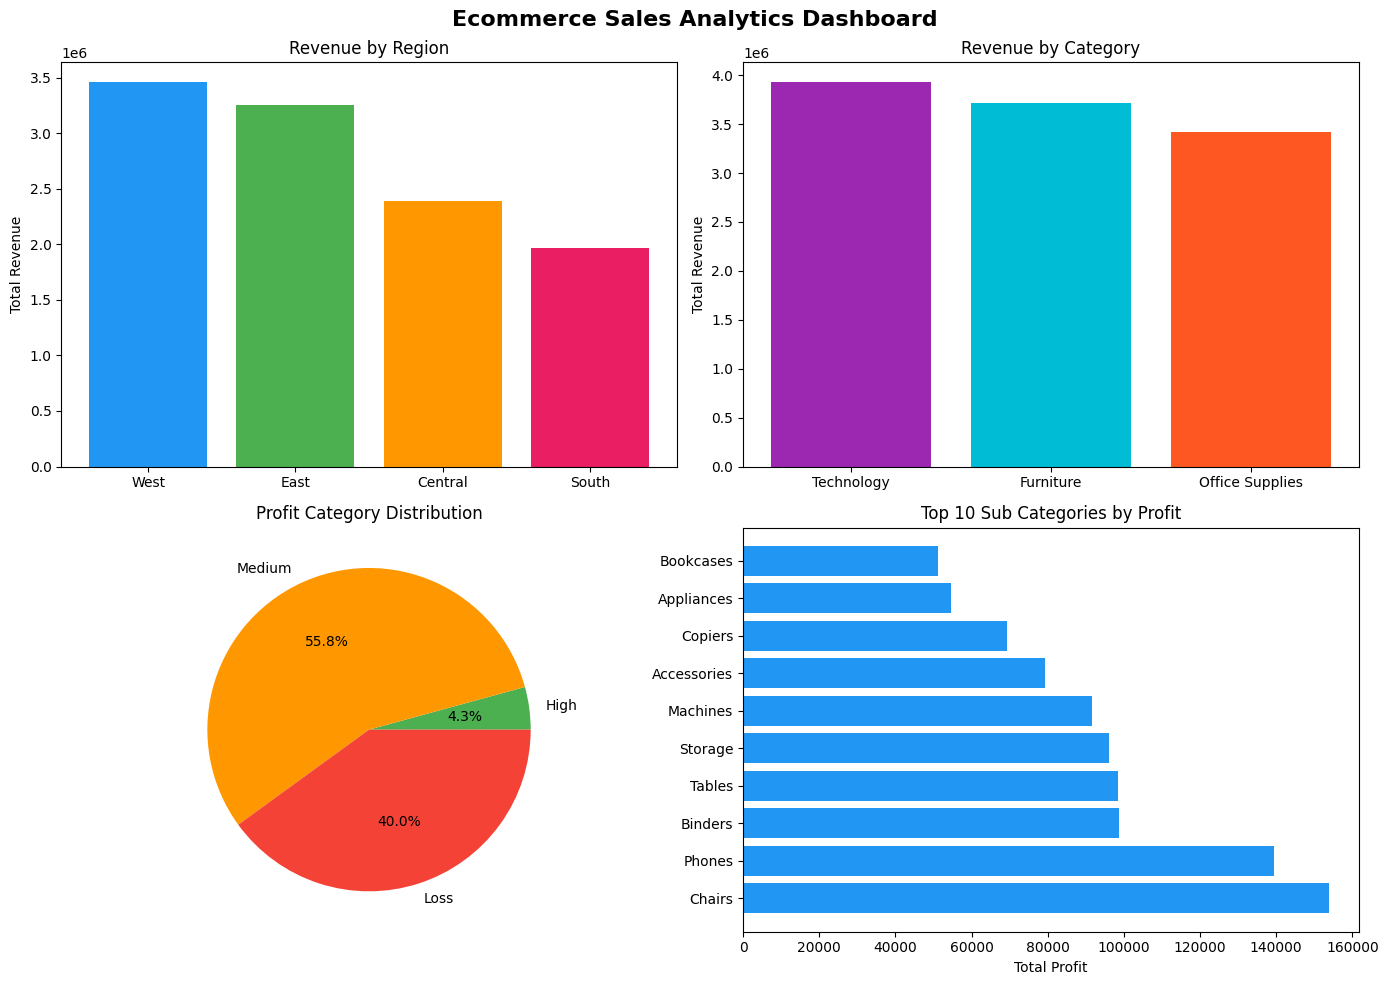

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to Pandas for visualization
region_df = df_transformed.groupBy("Region") \
    .agg(round(sum("Revenue"), 2).alias("Total Revenue")) \
    .orderBy(desc("Total Revenue")) \
    .toPandas()

category_df = df_transformed.groupBy("Category") \
    .agg(round(sum("Revenue"), 2).alias("Total Revenue")) \
    .orderBy(desc("Total Revenue")) \
    .toPandas()

profit_df = df_transformed.groupBy("Profit Category") \
    .count() \
    .toPandas()

top_sub_df = df_transformed.groupBy("Sub Category") \
    .agg(round(sum("Profit"), 2).alias("Total Profit")) \
    .orderBy(desc("Total Profit")) \
    .limit(10) \
    .toPandas()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ecommerce Sales Analytics Dashboard', fontsize=16, fontweight='bold')

# Chart 1: Revenue by Region
axes[0, 0].bar(region_df['Region'], region_df['Total Revenue'], color=['#2196F3','#4CAF50','#FF9800','#E91E63'])
axes[0, 0].set_title('Revenue by Region')
axes[0, 0].set_ylabel('Total Revenue')

# Chart 2: Revenue by Category
axes[0, 1].bar(category_df['Category'], category_df['Total Revenue'], color=['#9C27B0','#00BCD4','#FF5722'])
axes[0, 1].set_title('Revenue by Category')
axes[0, 1].set_ylabel('Total Revenue')

# Chart 3: Profit Category Distribution
axes[1, 0].pie(profit_df['count'], labels=profit_df['Profit Category'], autopct='%1.1f%%', colors=['#4CAF50','#FF9800','#F44336'])
axes[1, 0].set_title('Profit Category Distribution')

# Chart 4: Top 10 Sub Categories by Profit
axes[1, 1].barh(top_sub_df['Sub Category'], top_sub_df['Total Profit'], color='#2196F3')
axes[1, 1].set_title('Top 10 Sub Categories by Profit')
axes[1, 1].set_xlabel('Total Profit')

plt.tight_layout()
plt.show()